# Jacobian unit-test figures — Test Case A

This notebook visualizes the figures behind **Test Case A** of
`tests/test_jacobian.py`
(`test_jacobian_no_rotation_recovers_model_gradients`), which tests
`dbof.utils.native_gradient.calculate_jacobian`.

**Test Case A idea.** The two rotations inside `calculate_jacobian`
compose to `R . J_model . R^T`. With the grid rotation set to the
identity (`CS=1, SN=0`) that reduces to `J_model = [[a, b], [e, f]]`,
so for the linear velocity fields `u = a*x + b*y`, `v = e*x + f*y`
the four returned components must equal the constant slopes
`a, b, e, f` everywhere on each face interior, to machine precision.

We **reuse the exact test code** (the fixtures and constants from
`test_jacobian.py`) to build the synthetic data and run the
function, then draw figures that make the assertions visible:

1. the four computed Jacobian components on a face,
2. the error vs. the analytic constants (interior ≈ machine zero),
3. a line cut showing the face-edge halo contamination that motivates
   the `EDGE_MARGIN` trim,
4. the interior-only error histogram the test asserts on.

Generated by JXP and Claude

In [1]:
# Imports at top (project convention). We import the test module itself
# so the figures are generated from the very same fixtures and constants
# the unit test uses.
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import dbof.utils.native_gradient as ng

# Make the repository's tests/ importable, then reuse its fixtures.
_REPO = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
_TESTS = os.path.join(_REPO, 'tests')
if _TESTS not in sys.path:
    sys.path.insert(0, _TESTS)

import test_jacobian as tng  # noqa: E402

print('EDGE_MARGIN =', tng.EDGE_MARGIN, '| N_FACES =', tng.N_FACES)

EDGE_MARGIN = 3 | N_FACES = 13


## 1. Build the synthetic data and run `calculate_jacobian`

These are the *same* parameters used by Test Case A: identity rotation
(`CS=1, SN=0`), uniform spacing `d=2500 m`, and realistic
`O(1e-5 s^-1)` velocity-gradient slopes `(a, b, e, f)`.

In [2]:
# Parameters lifted verbatim from Test Case A.
d = 2500.0
a, b, e, f = 1.0e-5, 2.0e-5, -3.0e-5, 4.0e-5

# Identity rotation -> outputs should equal the model slopes (a, b, e, f).
ds, grid = tng.make_synthetic_grid(n=16, d=d, cs=1.0, sn=0.0)
u_x, v_y = tng.add_linear_velocity(ds, d, a, b, e, f)

# Run the function under test.
dudl, dudp, dvdl, dvdp = ng.calculate_jacobian(u_x, v_y, ds, grid)

# Pair each computed component with its analytic target and label.
components = [
    (dudl, a, r'$\partial u_\lambda / \partial \lambda$', 'a'),
    (dudp, b, r'$\partial u_\lambda / \partial \phi$', 'b'),
    (dvdl, e, r'$\partial v_\phi / \partial \lambda$', 'e'),
    (dvdp, f, r'$\partial v_\phi / \partial \phi$', 'f'),
]

FACE = 0  # all 13 faces are identical by construction; show face 0.
print('output dims:', dudl.dims, '| shape:', dudl.shape)

output dims: ('face', 'j', 'i') | shape: (13, 16, 16)


## 2. The four computed Jacobian components on a face

Each panel is a constant interior field equal to its analytic target
(`a`, `b`, `e`, `f`). The dashed box marks the `EDGE_MARGIN` interior
the test compares against; the colored ring outside it is the
cross-face halo contamination, excluded from the comparison.

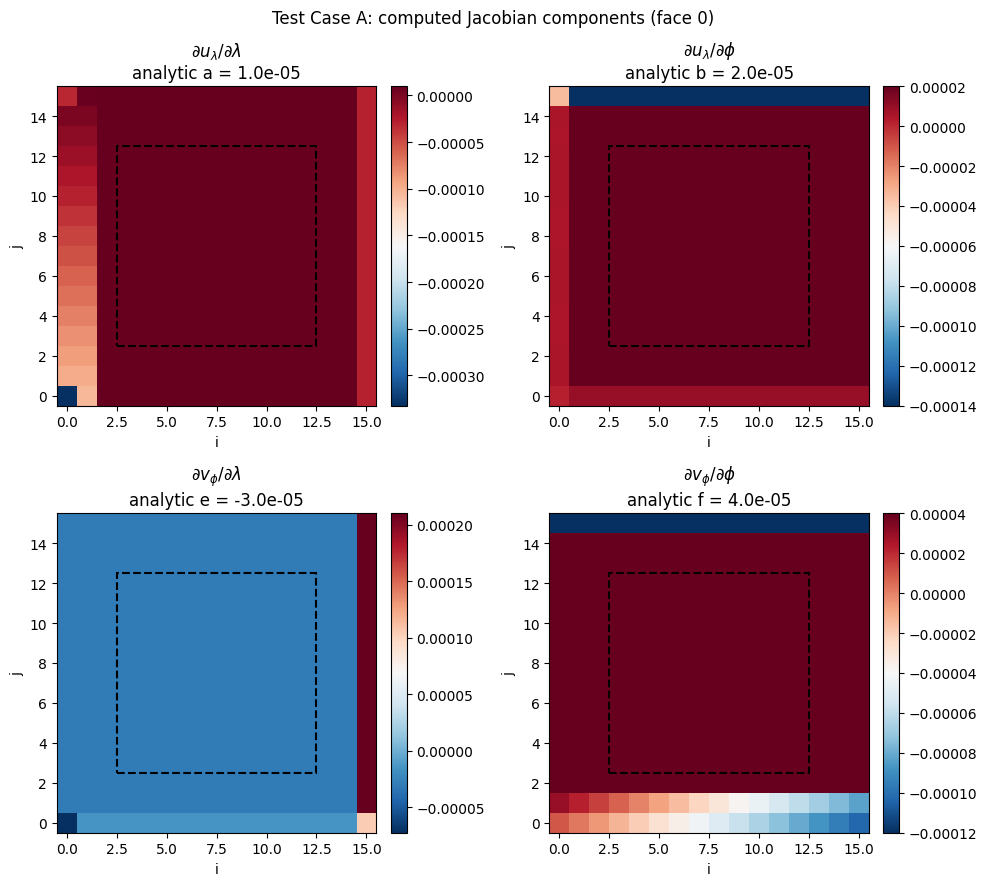

In [3]:
m = tng.EDGE_MARGIN
n = ds.sizes['i']

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, (da, target, label, sym) in zip(axes.ravel(), components):
    img = da.isel(face=FACE).values
    pcm = ax.imshow(img, origin='lower', cmap='RdBu_r')
    fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
    # Dashed rectangle = the interior the test asserts on.
    ax.add_patch(Rectangle((m - 0.5, m - 0.5), n - 2 * m, n - 2 * m,
                           fill=False, ec='k', ls='--', lw=1.5))
    ax.set_title(f'{label}\nanalytic {sym} = {target:.1e}')
    ax.set_xlabel('i')
    ax.set_ylabel('j')

fig.suptitle('Test Case A: computed Jacobian components (face %d)' % FACE)
fig.tight_layout()
plt.show()

## 3. Error vs. the analytic constants

We subtract each analytic target and plot `computed - target`. The
interior is at machine precision (note the `~1e-20` colorbar scale);
only the outer ring deviates — exactly the cells the test trims.

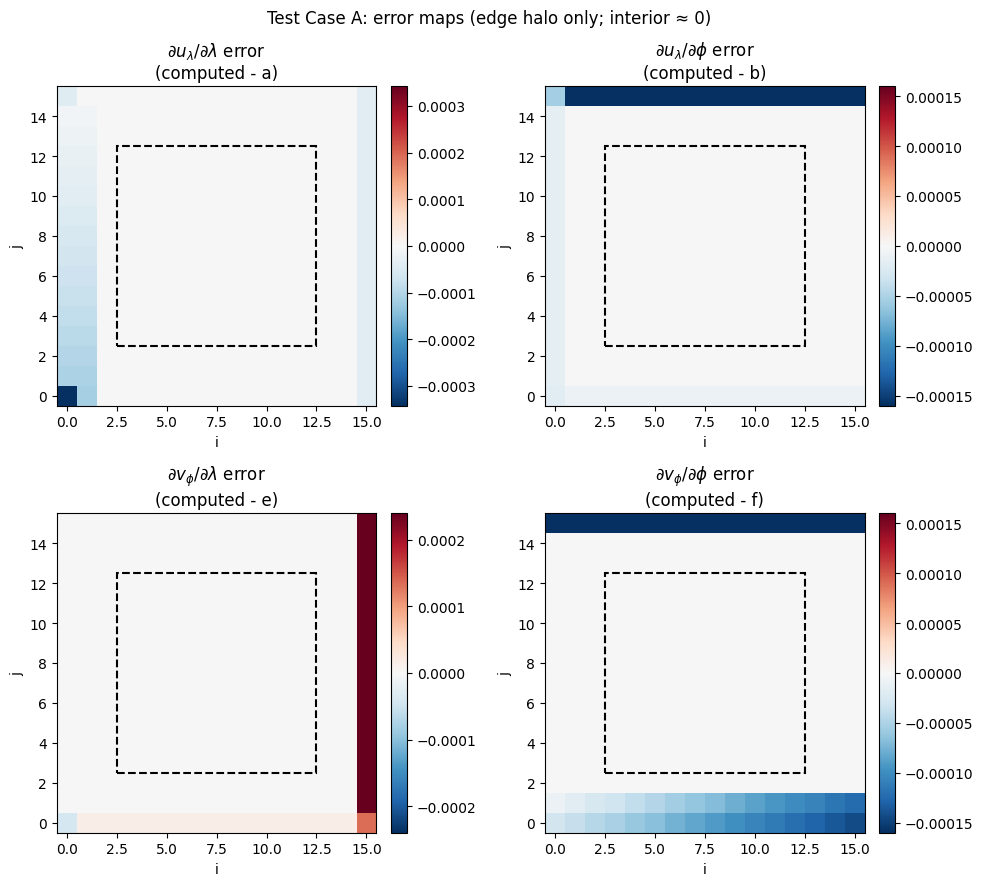

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, (da, target, label, sym) in zip(axes.ravel(), components):
    err = da.isel(face=FACE).values - target
    # Symmetric color scale driven by the (large) edge error.
    vmax = np.nanmax(np.abs(err)) or 1.0
    pcm = ax.imshow(err, origin='lower', cmap='RdBu_r',
                    vmin=-vmax, vmax=vmax)
    fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
    ax.add_patch(Rectangle((m - 0.5, m - 0.5), n - 2 * m, n - 2 * m,
                           fill=False, ec='k', ls='--', lw=1.5))
    ax.set_title(f'{label} error\n(computed - {sym})')
    ax.set_xlabel('i')
    ax.set_ylabel('j')

fig.suptitle('Test Case A: error maps (edge halo only; interior ≈ 0)')
fig.tight_layout()
plt.show()

## 4. Why `EDGE_MARGIN` exists: a line cut across a face

A single row of `du_lambda/dlambda` shows the interior pinned to `a`
while the outermost cells jump where the `face_connections` halo
injects the neighbouring face's (inconsistent) linear field. The
shaded bands are the trimmed `EDGE_MARGIN` cells.

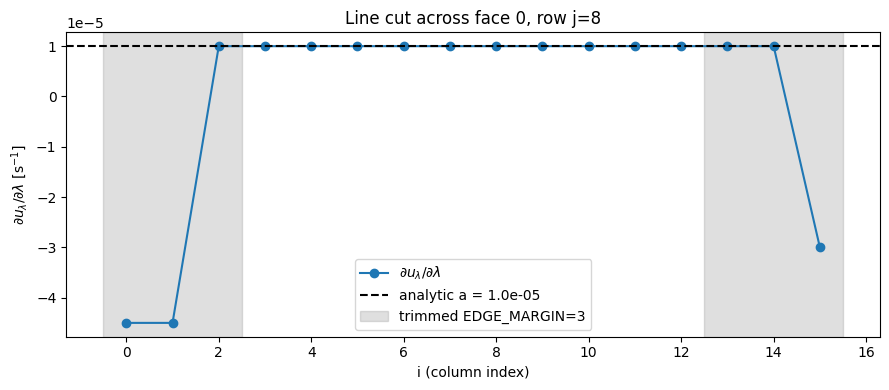

In [5]:
row = n // 2  # a representative interior row index (j)
cut = dudl.isel(face=FACE, j=row).values

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(n), cut, 'o-', label=r'$\partial u_\lambda/\partial\lambda$')
ax.axhline(a, color='k', ls='--', label=f'analytic a = {a:.1e}')
# Shade the trimmed margins on both edges.
ax.axvspan(-0.5, m - 0.5, color='grey', alpha=0.25)
ax.axvspan(n - m - 0.5, n - 0.5, color='grey', alpha=0.25,
           label=f'trimmed EDGE_MARGIN={m}')
ax.set_xlabel('i (column index)')
ax.set_ylabel(r'$\partial u_\lambda/\partial\lambda$ [s$^{-1}$]')
ax.set_title('Line cut across face %d, row j=%d' % (FACE, row))
ax.legend()
fig.tight_layout()
plt.show()

## 5. The assertion the test makes

Test Case A asserts that each component's *interior* matches its
analytic target with `rtol=1e-9`. Here we reproduce that interior trim
with the test's own `interior()` helper and show the relative error
distribution — all bars sit far below the `1e-9` tolerance line.

a: max interior rel. error = 3.56e-15
b: max interior rel. error = 1.36e-15
e: max interior rel. error = 1.02e-15
f: max interior rel. error = 8.47e-16


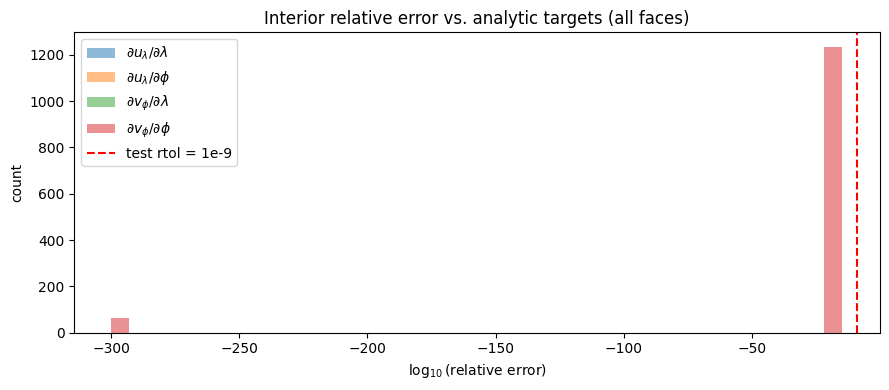

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
for da, target, label, sym in components:
    # Reuse the test's interior() so the figure matches the assertion.
    vals = tng.interior(da).values.ravel()
    rel = np.abs(vals - target) / np.abs(target)
    ax.hist(np.log10(rel + 1e-300), bins=40, alpha=0.5, label=label)
    print(f'{sym}: max interior rel. error = {rel.max():.2e}')

ax.axvline(np.log10(1e-9), color='r', ls='--',
           label='test rtol = 1e-9')
ax.set_xlabel(r'$\log_{10}$(relative error)')
ax.set_ylabel('count')
ax.set_title('Interior relative error vs. analytic targets (all faces)')
ax.legend()
fig.tight_layout()
plt.show()

## 6. Run the actual unit test

Finally, call the test function itself. No exception means Test Case A
passes — the figures above are the visual companion to this assertion.

In [7]:
tng.test_jacobian_no_rotation_recovers_model_gradients()
print('Test Case A passed.')

Test Case A passed.
